### Smart Wardrobe Assistant — ML Lab Project

Algorithms Used:

Logistic Regression → Classify clothing occasion    
Decision Tree → Match top with bottom    
Linear Regression → Score outfit compatibility    
Ridge Regression → Regularized scoring     

Lasso Regression → Feature selection   
Polynomial Regression → Non-linear interactions    

Dataset: Fashion Product Images Dataset (Kaggle)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score, precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE


In [6]:
# Step 1: Load the Dataset
df = pd.read_csv(r"C:\Users\harsh\OneDrive\Documents\MLPractical\styles.csv", on_bad_lines='skip')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (44424, 10)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName
0,15970,Men,Apparel,Topwear,Shirts,Navy Blue,Fall,2011.0,Casual,Turtle Check Men Navy Blue Shirt
1,39386,Men,Apparel,Bottomwear,Jeans,Blue,Summer,2012.0,Casual,Peter England Men Party Blue Jeans
2,59263,Women,Accessories,Watches,Watches,Silver,Winter,2016.0,Casual,Titan Women Silver Watch
3,21379,Men,Apparel,Bottomwear,Track Pants,Black,Fall,2011.0,Casual,Manchester United Men Solid Black Track Pants
4,53759,Men,Apparel,Topwear,Tshirts,Grey,Summer,2012.0,Casual,Puma Men Grey T-shirt


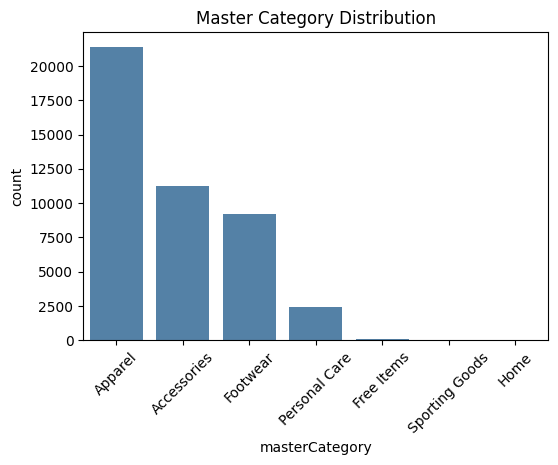

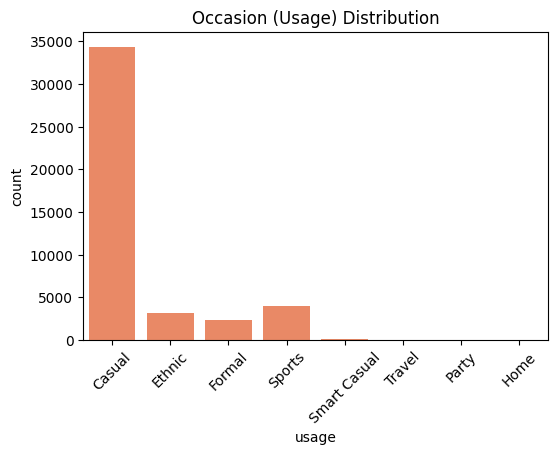

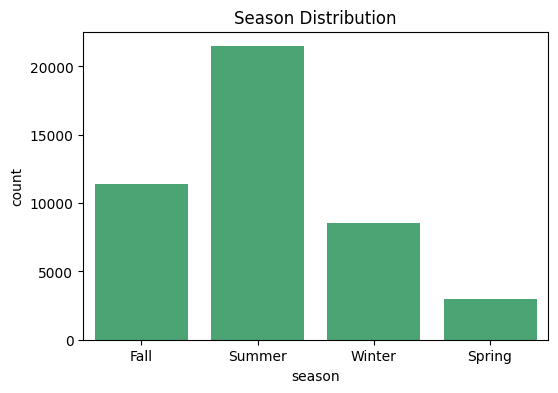

Missing Values:
 baseColour             15
season                 21
year                    1
usage                 317
productDisplayName      7
dtype: int64


In [7]:
# Step 2: Exploratory Data Analysis (EDA)

# 1. 
plt.figure(figsize=(6,4))
sns.countplot(x='masterCategory', data=df, color='steelblue')
plt.title('Master Category Distribution')
plt.xticks(rotation=45)
plt.show()

# 2.
plt.figure(figsize=(6,4))
sns.countplot(x='usage', data=df, color='coral')
plt.title('Occasion (Usage) Distribution')
plt.xticks(rotation=45)
plt.show()

# 3. 
plt.figure(figsize=(6,4))
sns.countplot(x='season', data=df, color='mediumseagreen')
plt.title('Season Distribution')
plt.show()

# 4. 
print("Missing Values:\n", df.isnull().sum()[df.isnull().sum() > 0])

In [8]:
# Step 3: Data Preprocessing

df = df[df['masterCategory'] == 'Apparel'].copy()
df = df.dropna(subset=['usage']).reset_index(drop=True)
df['baseColour'] = df['baseColour'].fillna('Black')
df['season'] = df['season'].fillna('All Season')


NEUTRAL = ['Black','White','Grey','Navy Blue','Beige','Brown','Cream','Charcoal','Off White','Grey Melange','Silver','Tan']
WARM = ['Red','Orange','Yellow','Pink','Maroon','Peach','Coral','Rust','Burgundy','Magenta','Rose','Mustard']
COOL = ['Blue','Green','Teal','Purple','Lavender','Mint','Turquoise','Olive','Sea Green','Sky Blue','Cyan','Emerald']

def color_cat(c):
    if c in NEUTRAL: return 'neutral'
    elif c in WARM: return 'warm'
    elif c in COOL: return 'cool'
    return 'other'

def color_harmony(c1, c2):
    a, b = color_cat(c1), color_cat(c2)
    if a == 'neutral' or b == 'neutral': return 0.9
    if a == b: return 0.8
    if set([a,b]) == set(['warm','cool']): return 0.4
    return 0.6

df['color_category'] = df['baseColour'].apply(color_cat)
df['is_neutral'] = df['baseColour'].apply(lambda c: 1 if c in NEUTRAL else 0)

# Label Encoding
le_gender = LabelEncoder()
le_usage = LabelEncoder()
le_season = LabelEncoder()
le_colour = LabelEncoder()
le_color_cat = LabelEncoder()

df['gender_enc'] = le_gender.fit_transform(df['gender'])
df['usage_enc'] = le_usage.fit_transform(df['usage'])
df['season_enc'] = le_season.fit_transform(df['season'])
df['baseColour_enc'] = le_colour.fit_transform(df['baseColour'])
df['color_category_enc'] = le_color_cat.fit_transform(df['color_category'])


df['masterCategory_enc'] = LabelEncoder().fit_transform(df['masterCategory'])
df['subCategory_enc'] = LabelEncoder().fit_transform(df['subCategory'])
df['articleType_enc'] = LabelEncoder().fit_transform(df['articleType'])

print("Cleaned Shape:", df.shape)
print("Target Classes:", list(le_usage.classes_))

Cleaned Shape: (21373, 20)
Target Classes: ['Casual', 'Ethnic', 'Formal', 'Party', 'Smart Casual', 'Sports', 'Travel']


Model 1: Logistic Regression (Occasion Classification)    
Goal: Given a clothing item's features (color, type, season), predict whether it is Casual, Formal, Party, or Sports wear.

Skipping classes with too few examples for SMOTE: ['Travel']
Class distribution before SMOTE:
Class 0: 12480
Class 1: 2332
Class 2: 951
Class 3: 18
Class 4: 18
Class 5: 1298
Class distribution after SMOTE:
Class 0: 12480
Class 1: 12480
Class 2: 12480
Class 3: 12480
Class 4: 12480
Class 5: 12480
Accuracy  : 0.3658
Precision : 0.7220
Recall    : 0.3658
F1-Score  : 0.4240

Classification Report:
              precision    recall  f1-score   support

      Casual       0.85      0.27      0.41      3122
      Ethnic       0.61      0.84      0.71       628
      Formal       0.02      0.03      0.02       221
       Party       0.01      0.75      0.02         4
Smart Casual       0.00      0.00      0.00         3
      Sports       0.17      0.60      0.26       297

    accuracy                           0.37      4275
   macro avg       0.27      0.41      0.24      4275
weighted avg       0.72      0.37      0.42      4275



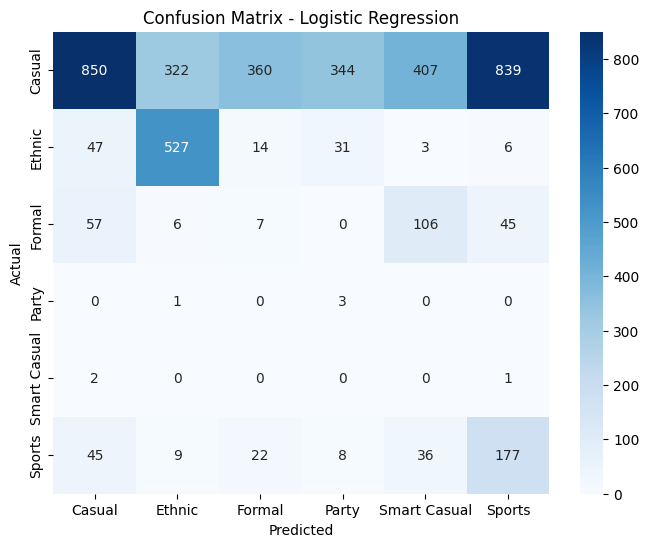

In [9]:
# Model 1: Logistic Regression (Occasion Classification)

# 1. 
FEATURES = ['gender_enc','masterCategory_enc','subCategory_enc','articleType_enc','baseColour_enc','season_enc','is_neutral','color_category_enc']
X = df[FEATURES].values
Y = df['usage_enc'].values

# Remove extremely rare classes that cannot be handled by SMOTE
classes, counts = np.unique(Y, return_counts=True)
min_samples_for_smote = 2
eligible_classes = classes[counts >= min_samples_for_smote]
rare_classes = classes[counts < min_samples_for_smote]
if len(rare_classes) > 0:
    rare_labels = le_usage.inverse_transform(rare_classes)
    print("Skipping classes with too few examples for SMOTE:", list(rare_labels))

mask = np.isin(Y, eligible_classes)
X = X[mask]
Y = Y[mask]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print("Class distribution before SMOTE:")
classes, counts = np.unique(Y_train, return_counts=True)
for cls, count in zip(classes, counts):
    print(f"Class {cls}: {count}")

# Handle class imbalance with SMOTE
smote = SMOTE(random_state=42, k_neighbors=1)
X_train, Y_train = smote.fit_resample(X_train, Y_train)

print("Class distribution after SMOTE:")
classes, counts = np.unique(Y_train, return_counts=True)
for cls, count in zip(classes, counts):
    print(f"Class {cls}: {count}")

# 2. 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 3. 
log_reg = LogisticRegression(solver='lbfgs', max_iter=5000, class_weight='balanced')
log_reg.fit(X_train, Y_train)

# 4. 
pred_y = log_reg.predict(X_test)

# 5. 
print(f"Accuracy  : {accuracy_score(Y_test, pred_y):.4f}")
print(f"Precision : {precision_score(Y_test, pred_y, average='weighted', zero_division=0):.4f}")
print(f"Recall    : {recall_score(Y_test, pred_y, average='weighted', zero_division=0):.4f}")
print(f"F1-Score  : {f1_score(Y_test, pred_y, average='weighted', zero_division=0):.4f}")

# 6. 
print("\nClassification Report:")
present_classes = np.unique(Y_test)
class_names = [le_usage.classes_[i] for i in present_classes]
print(classification_report(Y_test, pred_y, labels=present_classes, target_names=class_names, zero_division=0))

# 7. 
cm = confusion_matrix(Y_test, pred_y, labels=present_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()




Random Forest Accuracy  : 0.6517
Random Forest Precision : 0.8758
Random Forest Recall    : 0.6517
Random Forest F1-Score  : 0.7083

Random Forest Classification Report:
              precision    recall  f1-score   support

      Casual       0.96      0.56      0.71      3122
      Ethnic       0.96      0.96      0.96       628
      Formal       0.31      0.75      0.44       221
       Party       0.12      0.75      0.21         4
Smart Casual       0.00      0.00      0.00         3
      Sports       0.23      0.85      0.36       297

    accuracy                           0.65      4275
   macro avg       0.43      0.65      0.45      4275
weighted avg       0.88      0.65      0.71      4275



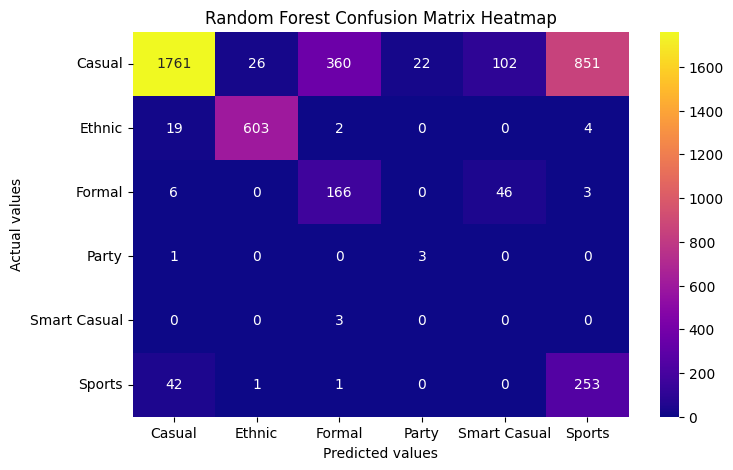

Class distribution in test set:
Class 0: 3122
Class 1: 628
Class 2: 221
Class 3: 4
Class 4: 3
Class 5: 297


In [10]:
# Model 1b: Random Forest (Occasion Classification with class weights)

# Use the same balanced training data from above
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
rf.fit(X_train, Y_train)

# 4. 
pred_y_rf = rf.predict(X_test)

# 5. 
print(f"Random Forest Accuracy  : {accuracy_score(Y_test, pred_y_rf):.4f}")
print(f"Random Forest Precision : {precision_score(Y_test, pred_y_rf, average='weighted', zero_division=0):.4f}")
print(f"Random Forest Recall    : {recall_score(Y_test, pred_y_rf, average='weighted', zero_division=0):.4f}")
print(f"Random Forest F1-Score  : {f1_score(Y_test, pred_y_rf, average='weighted', zero_division=0):.4f}")

# 6. 
print("\nRandom Forest Classification Report:")
print(classification_report(Y_test, pred_y_rf, labels=present_classes, target_names=class_names, zero_division=0))

# 7. 
cm_rf = confusion_matrix(Y_test, pred_y_rf)
plt.figure(figsize=(8, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="plasma",
            xticklabels=class_names,
            yticklabels=class_names)
plt.xlabel("Predicted values")
plt.ylabel("Actual values")
plt.title("Random Forest Confusion Matrix Heatmap")
plt.show()

# check the imbalance handling by SMOTE
print("Class distribution in test set:")
classes, counts = np.unique(Y_test, return_counts=True)
for cls, count in zip(classes, counts):
    print(f"Class {cls}: {count}")
        

Model 2: Decision Tree (Outfit Matching)   
Goal: Given a top's features, occasion, and season, predict which type of bottom (Jeans, Trousers, Shorts) matches best with it.

Training Accuracy: 0.9985
Testing Accuracy:  0.9987

Classification Report:
              precision    recall  f1-score   support

      Capris       0.97      1.00      0.99        75
    Churidar       1.00      1.00      1.00        19
       Jeans       1.00      1.00      1.00      2024
    Leggings       1.00      1.00      1.00         8
     Patiala       1.00      1.00      1.00       183
      Salwar       1.00      1.00      1.00       276
      Shorts       0.99      1.00      1.00       286
    Swimwear       0.00      0.00      0.00         2
 Track Pants       1.00      0.89      0.94        18
    Trousers       1.00      1.00      1.00       182

    accuracy                           1.00      3073
   macro avg       0.90      0.89      0.89      3073
weighted avg       1.00      1.00      1.00      3073



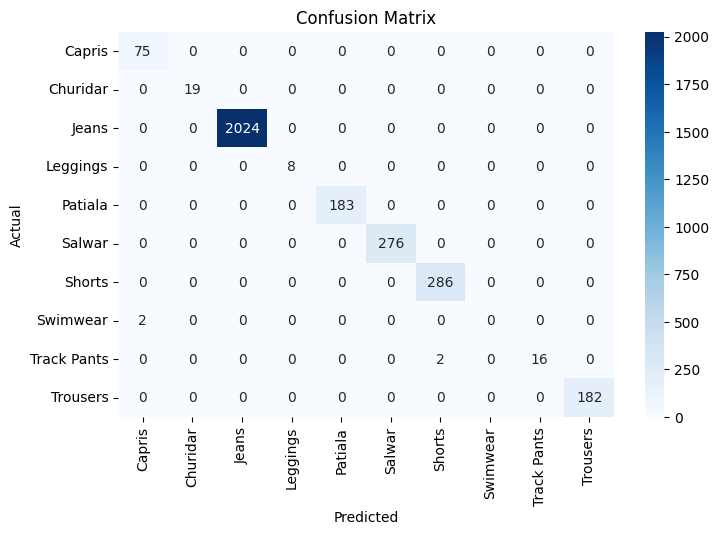

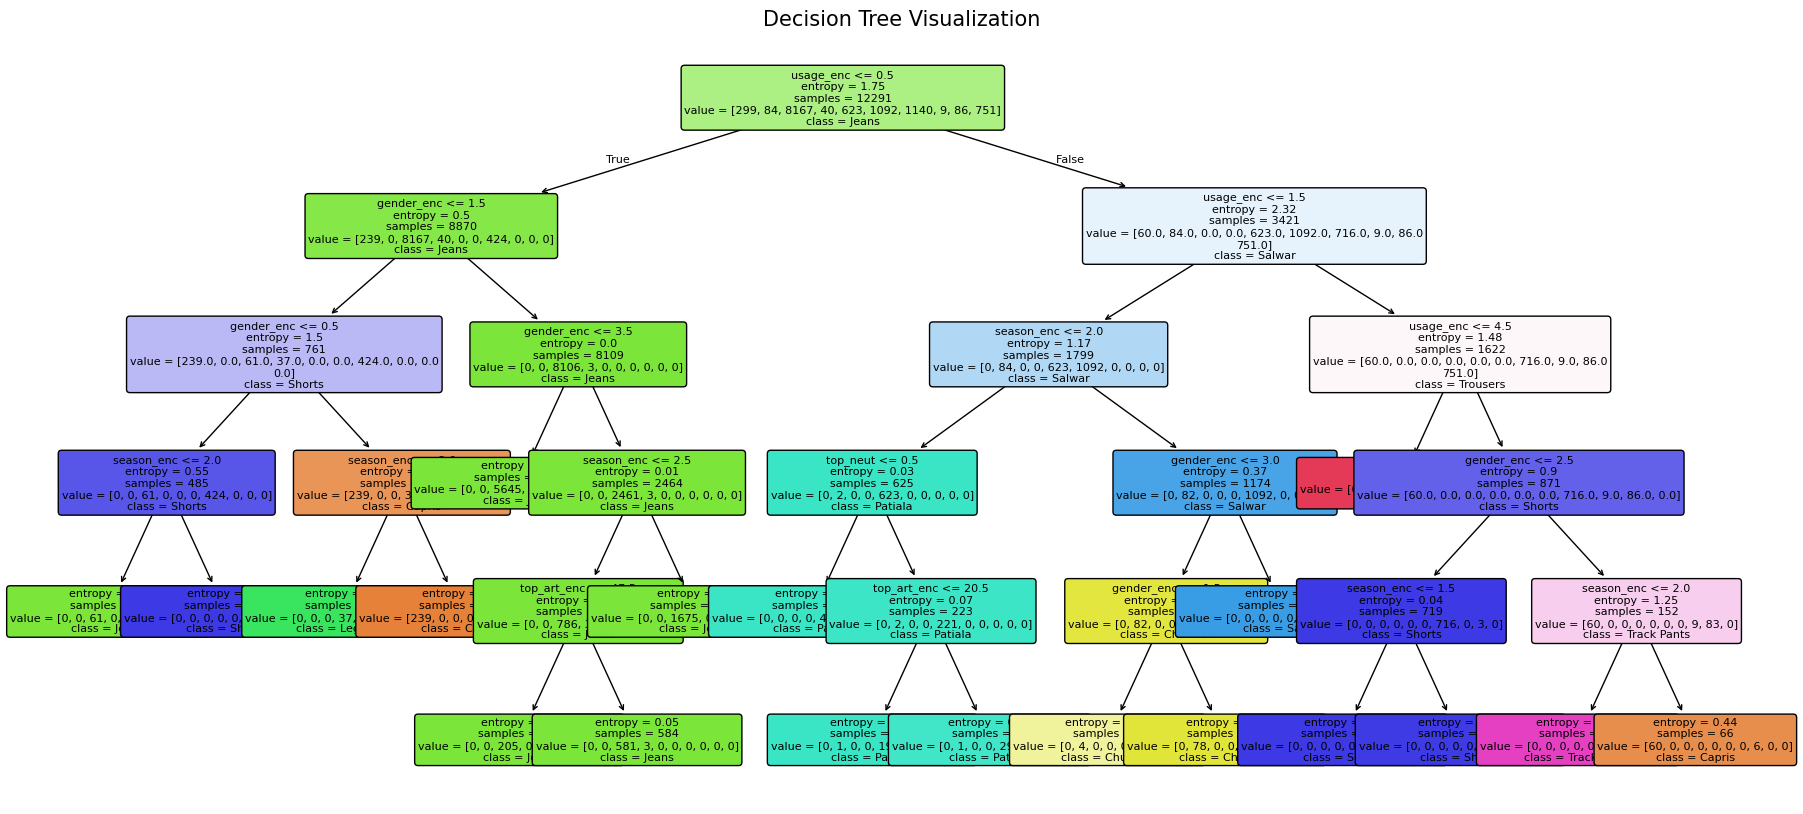

In [11]:
# Model 2: Decision Tree (Outfit Matching)

# 1. Create Training Data for Matching (Top + Bottom Pairs)
tops = df[df['subCategory'] == 'Topwear']
bottoms = df[df['subCategory'] == 'Bottomwear']

pairs = []
for _, top in tops.iterrows():
    match = bottoms[(bottoms['usage']==top['usage']) & (bottoms['season']==top['season']) & (bottoms['gender']==top['gender'])]
    if len(match) > 0:
        pairs.append({'top_art_enc': top['articleType_enc'], 'top_col_enc': top['color_category_enc'], 
                      'top_neut': top['is_neutral'], 'season_enc': top['season_enc'], 'usage_enc': top['usage_enc'], 
                      'gender_enc': top['gender_enc'], 'best_bottom': match['articleType'].mode()[0]})

pair_df = pd.DataFrame(pairs)

# 2. Feature Transformation (Encoding)
le_bot = LabelEncoder()
pair_df['best_bot_enc'] = le_bot.fit_transform(pair_df['best_bottom'])

TREE_FEATS = ['top_art_enc','top_col_enc','top_neut','season_enc','usage_enc','gender_enc']
X = pair_df[TREE_FEATS].values
y = pair_df['best_bot_enc'].values

# 3. 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Train Decision Tree Classifier
model = DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=5, random_state=42)
model.fit(X_train, y_train)

# 5. 
y_pred = model.predict(X_test)

# 6. Check for Overfitting
train_acc = model.score(X_train, y_train)
test_acc = accuracy_score(y_test, y_pred)
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy:  {test_acc:.4f}")

# 7. 
print("\nClassification Report:")
present_classes = np.unique(y_test)
class_names = [le_bot.classes_[i] for i in present_classes]
print(classification_report(y_test, y_pred, labels=present_classes, target_names=class_names, zero_division=0))

# 8. 
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 9. 
plt.figure(figsize=(22, 10)) 
plot_tree(model, 
          filled=True, 
          feature_names=TREE_FEATS, 
          class_names=list(le_bot.classes_), 
          rounded=True,      
          fontsize=8,        
          precision=2       
)
plt.title("Decision Tree Visualization", fontsize=15)
plt.show()

Models : Linear, Ridge, Lasso, Polynomial Regression (Outfit Scoring)  
Goal: Create top-bottom pairs, calculate a compatibility score (0-100), and train regressors to predict this score.  

Linear: Basic scoring baseline    
Ridge: L2 regularization (handles many features)    
Lasso: L1 regularization (eliminates useless features by making coefficients 0)    
Polynomial: Captures non-linear interactions (e.g., color_match × occasion_match)    

In [12]:
# Models : Regression Models (Outfit Scoring)

# Step 1: Create pair dataset and target score
tops_sample = tops.sample(n=min(800, len(tops)), random_state=42)
pairs = []
for _, top in tops_sample.iterrows():
    matched_bottoms = bottoms[(bottoms['usage'] == top['usage']) &
                              (bottoms['season'] == top['season']) &
                              (bottoms['gender'] == top['gender'])]
    if len(matched_bottoms) == 0:
        continue
    bottom = matched_bottoms.sample(n=1, random_state=42).iloc[0]
    pairs.append({
        'top_art_enc': top['articleType_enc'],
        'top_col_enc': top['color_category_enc'],
        'top_neut': top['is_neutral'],
        'season_enc': top['season_enc'],
        'usage_enc': top['usage_enc'],
        'gender_enc': top['gender_enc'],
        'baseColour_top': top['baseColour'],
        'baseColour_bot': bottom['baseColour'],
        'is_neutral_top': top['is_neutral'],
        'is_neutral_bot': bottom['is_neutral'],
        'color_category_enc_top': top['color_category_enc'],
        'color_category_enc_bot': bottom['color_category_enc'],
        'usage_top': top['usage'],
        'usage_bot': bottom['usage'],
        'season_top': top['season'],
        'season_bot': bottom['season'],
        'gender_top': top['gender'],
        'gender_bot': bottom['gender']
    })

pairs_df = pd.DataFrame(pairs)
print("Initial pair count:", len(pairs_df))


max_pairs = 1000
if len(pairs_df) > max_pairs:
    pairs_df = pairs_df.sample(n=max_pairs, random_state=42).reset_index(drop=True)
    print(f"Reduced pairs_df to {max_pairs} samples for regression training")

pairs_df['same_usage'] = (pairs_df['usage_top'] == pairs_df['usage_bot']).astype(int)
pairs_df['same_season'] = (pairs_df['season_top'] == pairs_df['season_bot']).astype(int)
pairs_df['same_gender'] = (pairs_df['gender_top'] == pairs_df['gender_bot']).astype(int)

harmony_scores = []
for index, row in pairs_df.iterrows():
    score = color_harmony(row['baseColour_top'], row['baseColour_bot'])
    harmony_scores.append(score)
pairs_df['color_harmony'] = harmony_scores

pairs_df['has_neutral'] = ((pairs_df['is_neutral_top'] == 1) | (pairs_df['is_neutral_bot'] == 1)).astype(int)
pairs_df['both_neutral'] = ((pairs_df['is_neutral_top'] == 1) & (pairs_df['is_neutral_bot'] == 1)).astype(int)

np.random.seed(42)
pairs_df['score'] = (30 * pairs_df['same_usage'] + 20 * pairs_df['same_season'] + 15 * pairs_df['color_harmony'] + 15 * pairs_df['has_neutral'] + 10 * pairs_df['both_neutral'] + 10 * pairs_df['same_gender'] + np.random.normal(0, 8, len(pairs_df)))
pairs_df['score'] = pairs_df['score'].clip(0, 100)


SCORE_FEATURES = ['same_usage', 'same_season', 'same_gender', 'color_harmony', 
                  'has_neutral', 'both_neutral', 'is_neutral_top', 'is_neutral_bot',
                  'color_category_enc_top', 'color_category_enc_bot']
X = pairs_df[SCORE_FEATURES].values
y = pairs_df['score'].values


poly = PolynomialFeatures(degree=2)
poly_X = poly.fit_transform(X)
print("Shape after Polynomial Features:", poly_X.shape)


X_train, X_test, Y_train, Y_test = train_test_split(poly_X, y, test_size=0.2, random_state=42)


s = StandardScaler()
X_train_scaled = s.fit_transform(X_train)
X_test_scaled = s.transform(X_test)


Initial pair count: 797
Shape after Polynomial Features: (797, 66)


In [13]:
# Train Linear, Ridge, and Lasso on the Polynomial Data


lr = LinearRegression()
lr.fit(X_train_scaled, Y_train)

lasso = Lasso(alpha=1.0, max_iter=5000)
lasso.fit(X_train_scaled, Y_train)

ridge = Ridge(alpha=1.0, max_iter=5000)
ridge.fit(X_train_scaled, Y_train)


pred_lr = lr.predict(X_test_scaled)
pred_lasso = lasso.predict(X_test_scaled)
pred_ridge = ridge.predict(X_test_scaled)


print("Linear Regression")
print("MSE:", mean_squared_error(Y_test, pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, pred_lr)))
print("R2 Score:", r2_score(Y_test, pred_lr))


print("\nLasso Regression")
print("MSE:", mean_squared_error(Y_test, pred_lasso))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, pred_lasso)))
print("R2 Score:", r2_score(Y_test, pred_lasso))


print("\nRidge Regression")
print("MSE:", mean_squared_error(Y_test, pred_ridge))
print("RMSE:", np.sqrt(mean_squared_error(Y_test, pred_ridge)))
print("R2 Score:", r2_score(Y_test, pred_ridge))


print("\nLinear Regression Coefficients:")
print(lr.coef_)

print("\nLasso Coefficients (Notice the 0s - Feature Elimination):")
print(lasso.coef_)

print("\nRidge Coefficients:")
print(ridge.coef_)

Linear Regression
MSE: 43.8234676518512
RMSE: 6.61992958058099
R2 Score: 0.5797839408140879

Lasso Regression
MSE: 44.129501181478034
RMSE: 6.643003927552507
R2 Score: 0.576849435383797

Ridge Regression
MSE: 43.180136020849815
RMSE: 6.57115941222322
R2 Score: 0.5859527425364142

Linear Regression Coefficients:
[-2.87845212e-15 -7.77156117e-16  0.00000000e+00 -3.10862447e-15
 -1.93421293e+00  8.81529568e-01 -6.12371312e-02  2.27118965e-01
  3.08746433e-01  9.76460056e-01 -1.08686363e+00  0.00000000e+00
  1.43492963e-42 -5.73971851e-42 -1.93421293e+00  8.81529568e-01
 -6.12371312e-02  2.27118965e-01  3.08746433e-01  9.76460056e-01
 -1.08686363e+00  0.00000000e+00  0.00000000e+00 -1.93421293e+00
  8.81529568e-01 -6.12371312e-02  2.27118965e-01  3.08746433e-01
  9.76460056e-01 -1.08686363e+00  0.00000000e+00 -1.93421293e+00
  8.81529568e-01 -6.12371312e-02  2.27118965e-01  3.08746433e-01
  9.76460056e-01 -1.08686363e+00  3.42588972e+00  8.81529568e-01
 -6.12371312e-02  2.27118965e-01  3.0

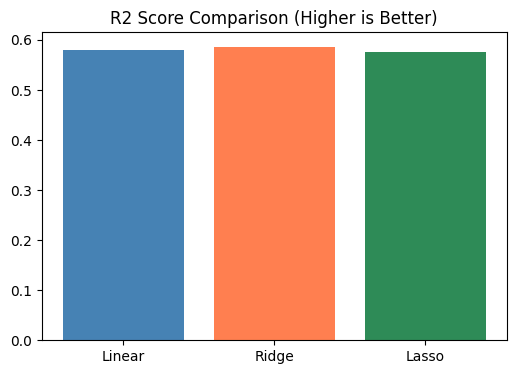

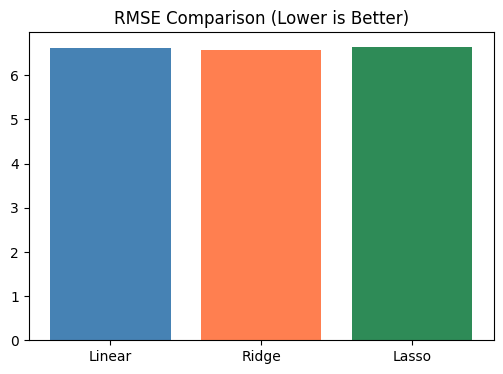

In [14]:
# Comparison Visualization


model_names = ['Linear', 'Ridge', 'Lasso']
r2_scores = [r2_score(Y_test, pred_lr), r2_score(Y_test, pred_ridge), r2_score(Y_test, pred_lasso)]
rmse_scores = [np.sqrt(mean_squared_error(Y_test, pred_lr)), np.sqrt(mean_squared_error(Y_test, pred_ridge)), np.sqrt(mean_squared_error(Y_test, pred_lasso))]


plt.figure(figsize=(6, 4))
plt.bar(model_names, r2_scores, color=['steelblue', 'coral', 'seagreen'])
plt.title('R2 Score Comparison (Higher is Better)')
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(model_names, rmse_scores, color=['steelblue', 'coral', 'seagreen'])
plt.title('RMSE Comparison (Lower is Better)')
plt.show()

In [15]:
# Final Demo: Complete Pipeline
def recommend_outfit(gender, occasion, season, top_n=3):
    print(f"\n{'='*70}")
    print(f"  Finding {occasion} outfit for {gender} — {season}")
    print(f"{'='*70}")
    
    # Step 1: Filter dataset
    tops_f = df[(df['subCategory']=='Topwear') & (df['gender']==gender) & (df['season'].isin([season, 'All Season']))]
    bots_f = df[(df['subCategory']=='Bottomwear') & (df['gender']==gender) & (df['season'].isin([season, 'All Season']))]
    
    if len(tops_f) == 0 or len(bots_f) == 0:
        print("  No items found.")
        return
    
    tops_f = tops_f.sample(n=min(60, len(tops_f)), random_state=42).copy()
    bots_f = bots_f.sample(n=min(60, len(bots_f)), random_state=42).copy()
    
    # Step 2: Logistic Regression - Filter by Occasion
    occ_idx = list(le_usage.classes_).index(occasion) if occasion in le_usage.classes_ else 0
    
    # ADDED .values HERE to fix the warning!
    tops_f['occ_prob'] = log_reg.predict_proba(scaler.transform(tops_f[FEATURES].values))[:, occ_idx]
    bots_f['occ_prob'] = log_reg.predict_proba(scaler.transform(bots_f[FEATURES].values))[:, occ_idx]
    
    # LOWERED from 0.12 to 0.05 so it doesn't filter out everything
    tops_f = tops_f[tops_f['occ_prob'] > 0.05]
    bots_f = bots_f[bots_f['occ_prob'] > 0.05]
    
    if len(tops_f) == 0 or len(bots_f) == 0:
        print("  No occasion match.")
        return
        
    # Step 3: Decision Tree - Match Top with Bottom
    tree_feats_list = []
    for _, row in tops_f.iterrows():
        feat = [row['articleType_enc'], row['color_category_enc'], row['is_neutral'], row['season_enc'], row['usage_enc'], row['gender_enc']]
        tree_feats_list.append(feat)
        
    tops_f['predicted_bottom'] = le_bot.inverse_transform(model.predict(np.array(tree_feats_list)))
    
    # Step 4: Create Pairs
    tops_f['key'] = 1
    bots_f['key'] = 1
    outfit_pairs = pd.merge(tops_f, bots_f, on='key', suffixes=('_top', '_bot')).drop('key', axis=1)
    
    # Step 5: Calculate Features
    outfit_pairs['dt_match'] = (outfit_pairs['articleType_bot'] == outfit_pairs['predicted_bottom']).astype(int)
    outfit_pairs['same_usage'] = (outfit_pairs['usage_top'] == outfit_pairs['usage_bot']).astype(int)
    outfit_pairs['same_season'] = (outfit_pairs['season_top'] == outfit_pairs['season_bot']).astype(int)
    outfit_pairs['same_gender'] = (outfit_pairs['gender_top'] == outfit_pairs['gender_bot']).astype(int)
    outfit_pairs['color_harmony'] = outfit_pairs.apply(lambda r: color_harmony(r['baseColour_top'], r['baseColour_bot']), axis=1)
    outfit_pairs['has_neutral'] = ((outfit_pairs['is_neutral_top'] == 1) | (outfit_pairs['is_neutral_bot'] == 1)).astype(int)
    outfit_pairs['both_neutral'] = ((outfit_pairs['is_neutral_top'] == 1) & (outfit_pairs['is_neutral_bot'] == 1)).astype(int)
    
    # Step 6: Ridge Regression - Score Outfits
    X_score = outfit_pairs[SCORE_FEATURES].fillna(0).values
    X_score_poly = poly.transform(X_score) 
    X_score_scaled = s.transform(X_score_poly)
    outfit_pairs['final_score'] = ridge.predict(X_score_scaled)
    
    # Step 7: Display Results
    best_outfits = outfit_pairs.nlargest(top_n, 'final_score')
    for i, (_, row) in enumerate(best_outfits.iterrows(), 1):
        print(f"\n  Outfit #{i} [Score: {row['final_score']:.1f}/100]")
        print(f"  Top:    {row['productDisplayName_top']} ({row['baseColour_top']})")
        print(f"  Bottom: {row['productDisplayName_bot']} ({row['baseColour_bot']})")
        print(f"  Color Match: {row['color_harmony']:.2f} | Tree Match: {row['dt_match']}")

# Run Tests
print("Test 1:")
recommend_outfit('Men', 'Casual', 'Summer')

print("\nTest 2:")
recommend_outfit('Women', 'Formal', 'Winter')

print("\nTest 3:")
recommend_outfit('Women', 'Party', 'Summer')

Test 1:

  Finding Casual outfit for Men — Summer

  Outfit #1 [Score: 96.1/100]
  Top:    Lee Men's Bottle Grey T-shirt (Beige)
  Bottom: Timberland Men's Cycling Pod Chino Khaki Pant (Cream)
  Color Match: 0.90 | Tree Match: 0

  Outfit #2 [Score: 96.1/100]
  Top:    Lee Men's Bottle Grey T-shirt (Beige)
  Bottom: Peter England Men Black Jeans (Black)
  Color Match: 0.90 | Tree Match: 1

  Outfit #3 [Score: 96.1/100]
  Top:    Lee Men's Bottle Grey T-shirt (Beige)
  Bottom: HIghlander Men Grey Trousers (Grey)
  Color Match: 0.90 | Tree Match: 0

Test 2:

  Finding Formal outfit for Women — Winter

  Outfit #1 [Score: 96.1/100]
  Top:    Jockey Women Black Racer Back Top (Black)
  Bottom: Puma Women Black Shorts (Black)
  Color Match: 0.90 | Tree Match: 0

  Outfit #2 [Score: 96.1/100]
  Top:    Lee Women Black Shirt (Black)
  Bottom: French Connection Women Black Skirt (Black)
  Color Match: 0.90 | Tree Match: 0

  Outfit #3 [Score: 96.1/100]
  Top:    Lee Women Black Shirt (Black)
 